In [53]:
import numpy as np
import pandas as pd
import seaborn as sc
import matplotlib.pylab as plt

In [54]:
df = pd.read_csv("loan_approval_classification.csv")

In [55]:
df.head()

,age,annual_income,credit_score,loan_amount,employment_years,existing_loans,debt_to_income_ratio,monthly_expenses,savings_balance,loan_approved
0,21,150000,440,194000,5.4,0,0.37,13300,181000,0
1,43,187000,795,1127000,5.7,0,0.68,86600,638000,0
2,51,150000,648,826000,3.8,3,0.04,33300,0,1
3,40,181000,542,20000,7.2,2,0.09,5000,91000,0
4,27,150000,503,724000,6.1,1,0.47,40000,382000,1


In [56]:
df = df.drop(columns=['employment_years'])

In [57]:
df.head()

,age,annual_income,credit_score,loan_amount,existing_loans,debt_to_income_ratio,monthly_expenses,savings_balance,loan_approved
0,21,150000,440,194000,0,0.37,13300,181000,0
1,43,187000,795,1127000,0,0.68,86600,638000,0
2,51,150000,648,826000,3,0.04,33300,0,1
3,40,181000,542,20000,2,0.09,5000,91000,0
4,27,150000,503,724000,1,0.47,40000,382000,1


In [58]:
df.describe()

,age,annual_income,credit_score,loan_amount,existing_loans,debt_to_income_ratio,monthly_expenses,savings_balance,loan_approved
count,1500.000000,1.500000e+03,1500.000000,1.500000e+03,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,36.565333,4.148833e+05,652.402000,4.916487e+05,1.526667,0.388967,49884.400000,204402.000000,0.350667
std,12.259116,2.296783e+05,147.140688,2.994907e+05,1.112106,0.229170,27475.763047,211018.320414,0.477338
min,21.000000,1.500000e+05,300.000000,2.000000e+04,0.000000,0.020000,5000.000000,0.000000,0.000000
25%,25.000000,2.200000e+05,542.750000,2.500000e+05,1.000000,0.230000,32450.000000,0.000000,0.000000
50%,36.000000,3.770000e+05,668.000000,4.945000e+05,1.000000,0.370000,48500.000000,152000.000000,0.000000
75%,46.000000,5.532500e+05,765.250000,7.000000e+05,2.000000,0.530000,65400.000000,351000.000000,1.000000
max,65.000000,1.392000e+06,900.000000,1.684000e+06,5.000000,0.900000,150000.000000,957000.000000,1.000000


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1500 non-null   int64  
 1   annual_income         1500 non-null   int64  
 2   credit_score          1500 non-null   int64  
 3   loan_amount           1500 non-null   int64  
 4   existing_loans        1500 non-null   int64  
 5   debt_to_income_ratio  1500 non-null   float64
 6   monthly_expenses      1500 non-null   int64  
 7   savings_balance       1500 non-null   int64  
 8   loan_approved         1500 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 105.6 KB


<Axes: xlabel='loan_approved', ylabel='count'>

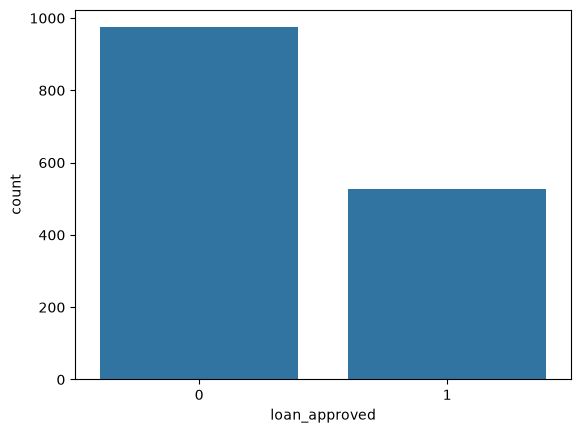

In [60]:
sc.countplot(x= df['loan_approved'])

<Axes: xlabel='age', ylabel='Count'>

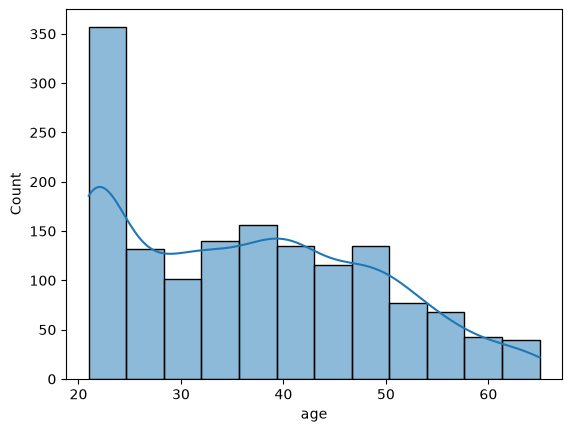

In [61]:
sc.histplot(x= df['age'], kde = True)

<Axes: ylabel='annual_income'>

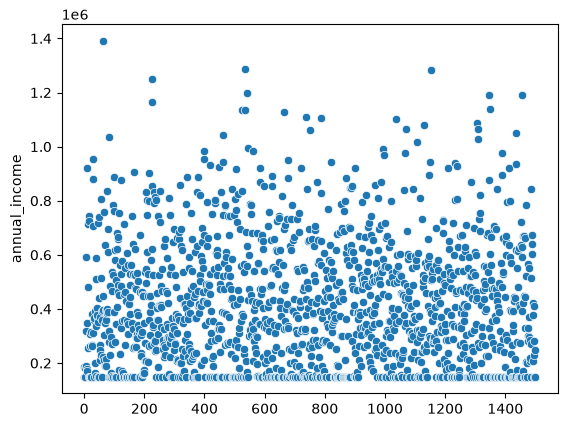

In [62]:
sc.scatterplot(df['annual_income'])

<Axes: xlabel='credit_score', ylabel='Count'>

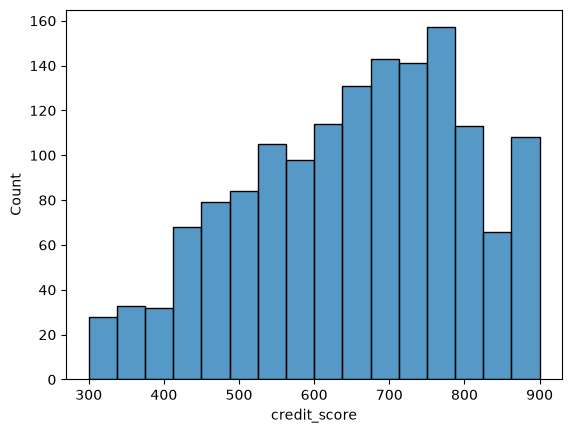

In [63]:
sc.histplot(x= df['credit_score'])

In [ ]:
df.head()

<Axes: xlabel='existing_loans', ylabel='count'>

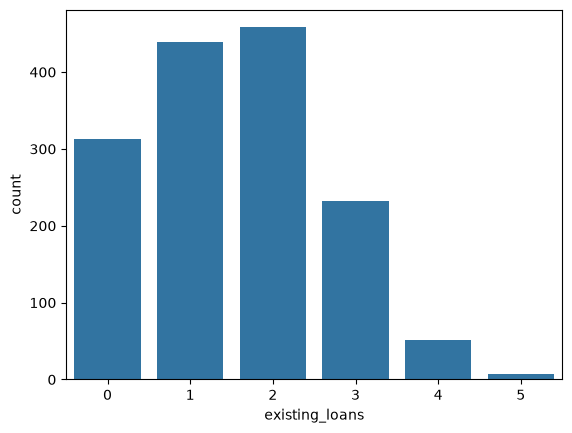

In [64]:
sc.countplot(x= df['existing_loans'])

<Axes: >

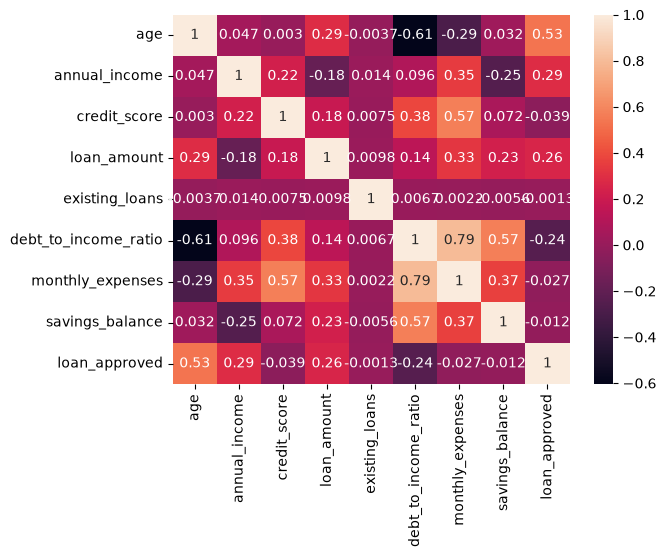

In [65]:
sc.heatmap(df.corr(numeric_only=True),annot=True)

In [66]:
df.columns

Index(['age', 'annual_income', 'credit_score', 'loan_amount', 'existing_loans',
       'debt_to_income_ratio', 'monthly_expenses', 'savings_balance',
       'loan_approved'],
      dtype='str')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [67]:
df.columns

Index(['age', 'annual_income', 'credit_score', 'loan_amount', 'existing_loans',
       'debt_to_income_ratio', 'monthly_expenses', 'savings_balance',
       'loan_approved'],
      dtype='str')

In [68]:
col = ['age', 'annual_income', 'credit_score', 'loan_amount', 'existing_loans',
       'debt_to_income_ratio', 'monthly_expenses', 'savings_balance']
df[col] = scaler.fit_transform(df[col])

In [69]:
df.head()

,age,annual_income,credit_score,loan_amount,existing_loans,debt_to_income_ratio,monthly_expenses,savings_balance,loan_approved
0,-1.270118,-1.153665,-1.444011,-0.994181,-1.373228,-0.082790,-1.331959,-0.110937,0
1,0.525063,-0.992516,0.969450,2.122147,-1.373228,1.270366,1.336736,2.055474,0
2,1.177857,-1.153665,-0.029927,1.116772,1.325255,-1.523247,-0.603802,-0.968969,1
3,0.280266,-1.018648,-0.750566,-1.575361,0.425761,-1.304996,-1.634145,-0.537583,0
4,-0.780523,-1.153665,-1.015707,0.776080,-0.473734,0.353712,-0.359870,0.841904,1


In [70]:
x = df.drop(columns=['loan_approved'])
y = df['loan_approved']

In [72]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: loan_approved, dtype: int64

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [74]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.30, random_state=42)

In [94]:
models = {
    "LogisticRegression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Navie_bays" : GaussianNB(),
    "Decision_tree" : DecisionTreeClassifier(),
    "Svc" : SVC()
}

In [95]:
result = []

In [96]:
from sklearn.metrics import f1_score

In [97]:
for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    result.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })


In [98]:
result

[{'Model': 'LogisticRegression', 'Accuracy': 0.8, 'F1 Score': 0.702},
 {'Model': 'KNN', 'Accuracy': 0.9067, 'F1 Score': 0.8688},
 {'Model': 'Navie_bays', 'Accuracy': 0.8222, 'F1 Score': 0.7619},
 {'Model': 'Decision_tree', 'Accuracy': 0.8244, 'F1 Score': 0.7524},
 {'Model': 'Svc', 'Accuracy': 0.8844, 'F1 Score': 0.8333}]